<a href="https://colab.research.google.com/github/prestonhixsonn-hash/Assignment-4.1-Implementing-a-Simplified-PEDO-Framework-for-Car-Design-/blob/main/Assignment_4_1_Implementing_a_Simplified_PEDO_Framework_for_Car_Design_Optimization_in_Jupyter_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing a Simplified PEDO Framework for Car Design Optimization

This notebook implements a simplified **Prompt Evolution Design Optimization (PEDO)** framework.
A population of *prompts* (encoded as genomes) is evolved with a genetic algorithm; each candidate
is rendered into a 2D car design and scored on a combined **aerodynamic + realism** fitness function.

## What this version fixes
The original notebook had three issues that prevented it from demonstrating optimization:
1. **The fitness curve was fabricated** (`random.uniform(0,1)`) instead of recording real scores.
2. **The aerodynamic score had no signal** - `1/|w/h-1.77|` is constant because every image is 512x512.
3. **The evolution loop could not finish** on CPU (Stable Diffusion is too slow), so it was interrupted.

This version: records *real* fitness history, scores the *car silhouette* (not the canvas), adds
**crossover + mutation + elitism**, embeds images inline, and runs in seconds via a lightweight
renderer when no GPU is available - while still supporting Stable Diffusion when one is.

## Objectives
- Generate 2D car designs (Stable Diffusion **or** a fast simulated renderer).
- Evolve prompts with a genetic algorithm (selection, crossover, mutation).
- Score designs on a silhouette-based aerodynamic proxy and a realism proxy.
- Track and visualise real fitness over generations.

## Setup
Lightweight dependencies always install. Stable Diffusion is optional (GPU recommended).

In [1]:
# Core (fast, always needed)
%pip install -q pillow numpy matplotlib

# OPTIONAL - only needed if USE_DIFFUSION = True below (requires a GPU runtime, e.g. Colab T4):
# %pip install -q diffusers transformers accelerate torch torchvision

## Configuration
A single switch chooses the renderer. Seeds make every run reproducible.

In [2]:
import random, numpy as np

SEED          = 42      # global seed -> reproducible evolution
POP_SIZE      = 8       # population size
GENERATIONS   = 6       # number of generations
ELITES        = 2       # best individuals carried over unchanged
MUTATION_RATE = 0.30    # per-gene mutation probability
W_AERO, W_REAL = 0.7, 0.3  # fitness weights (aerodynamics vs realism)

# Set True ONLY on a GPU runtime with diffusers installed. False -> fast simulated renderer.
USE_DIFFUSION = False

random.seed(SEED); np.random.seed(SEED)
print("Renderer:", "Stable Diffusion" if USE_DIFFUSION else "simulated (fast, no GPU)")

Renderer: simulated (fast, no GPU)


## Prompt encoding (the "chromosome")
Each design is a **genome**: one gene per design category. Genes map to numeric shape parameters,
so the same genome can be turned into a text prompt (for Stable Diffusion) *and* drawn directly.

In [3]:
GENE_POOL = {
    "roof":   {"low": 0.16, "sleek": 0.22, "standard": 0.34, "tall": 0.52, "boxy": 0.60},
    "front":  {"aerodynamic": 0.10, "sloped": 0.18, "upright": 0.50, "blunt": 0.58},
    "length": {"compact": 0.60, "standard": 0.82, "long": 1.00, "stretched": 1.12},
    "tail":   {"tapered": 0.12, "fastback": 0.20, "notchback": 0.42, "squared": 0.62},
}
CATEGORIES = list(GENE_POOL)

def random_genome():
    return {c: random.choice(list(GENE_POOL[c])) for c in CATEGORIES}

def genome_to_prompt(g):
    return (f"a {g['length']} car with a {g['roof']} roof, "
            f"{g['front']} front and {g['tail']} tail, side profile, white background")

print(genome_to_prompt(random_genome()))

a long car with a low roof, aerodynamic front and fastback tail, side profile, white background


## Task 1: Text-to-image generation
`render(genome)` returns a PIL image. With `USE_DIFFUSION=True` it calls Stable Diffusion;
otherwise it draws a parametric car silhouette so the rest of the pipeline runs anywhere.

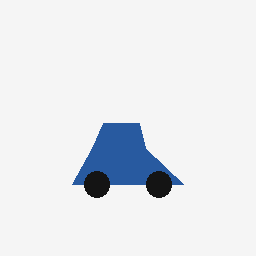

In [4]:
from PIL import Image, ImageDraw

BG = (245, 245, 245)

if USE_DIFFUSION:
    import torch
    from diffusers import StableDiffusionPipeline
    _pipe = StableDiffusionPipeline.from_pretrained(
        "CompVis/stable-diffusion-v1-4",
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    ).to("cuda" if torch.cuda.is_available() else "cpu")

def _render_diffusion(genome, seed):
    g = torch.Generator(device=_pipe.device).manual_seed(seed)
    return _pipe(genome_to_prompt(genome), num_inference_steps=25, generator=g).images[0]

def _render_simulated(genome, size=256):
    img = Image.new("RGB", (size, size), BG); d = ImageDraw.Draw(img)
    roof   = GENE_POOL["roof"][genome["roof"]]
    front  = GENE_POOL["front"][genome["front"]]
    length = GENE_POOL["length"][genome["length"]]
    tail   = GENE_POOL["tail"][genome["tail"]]
    W = size * 0.72 * min(length, 1.15); H = size * 0.46
    x0 = (size - W) / 2; yb = size * 0.72; body = H * 0.30; rh = H * roof
    body_pts = [(x0, yb), (x0 + W * front, yb - body),
                (x0 + W * (front + 0.10), yb - body - rh), (x0 + W * 0.60, yb - body - rh),
                (x0 + W * (0.60 + tail * 0.45), yb - body), (x0 + W, yb)]
    d.polygon(body_pts, fill=(40, 90, 160))
    r = size * 0.05
    for cx in (x0 + W * 0.22, x0 + W * 0.78):
        d.ellipse([cx - r, yb - r, cx + r, yb + r], fill=(20, 20, 20))
    return img

def render(genome, seed=SEED):
    return _render_diffusion(genome, seed) if USE_DIFFUSION else _render_simulated(genome)

# preview one design
render(random_genome())

## Task 3: Aerodynamic scoring (silhouette-based)
The original score read the *canvas* aspect ratio (constant for all images). Here we segment the
**car silhouette** and build a drag proxy: a *lower, smoother roofline* and *smaller frontal area*
score higher. This gives a real, design-dependent gradient.

In [5]:
def car_mask(image):
    a = np.asarray(image.convert("RGB")).astype(int)
    return np.abs(a - np.array(BG)).sum(2) > 60   # True where a car pixel is

def aerodynamic_score(image):
    m = car_mask(image); H, W = m.shape
    cols = np.where(m.any(0))[0]
    if len(cols) == 0:
        return 0.0
    top = np.array([np.argmax(m[:, c]) for c in cols])  # highest car pixel per column
    height = H - top                                    # silhouette height profile
    frontal = height.max() / H                          # frontal-area proxy (lower = better)
    roughness = np.mean(np.abs(np.diff(height))) / H    # roofline smoothness (smoother = better)
    return float(1.0 / (0.15 + 1.4 * frontal + 3.0 * roughness))

## Task 4: Penalising unrealistic designs
If a GPU/CLIP is available we score realism with **CLIP** ("a realistic car") - far more robust than
the original single hardcoded ImageNet index (751). Otherwise we use a lightweight plausibility
heuristic (a car should occupy a sensible fraction of the frame).

In [6]:
_clip = None
if USE_DIFFUSION:
    try:
        from transformers import CLIPProcessor, CLIPModel
        _clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").eval()
        _clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    except Exception as e:
        print("CLIP unavailable, using heuristic realism:", e)

def realism_score(image):
    if _clip is not None:
        import torch
        inp = _clip_proc(text=["a realistic car", "an abstract shape"],
                         images=image, return_tensors="pt", padding=True)
        with torch.no_grad():
            probs = _clip(**inp).logits_per_image.softmax(1)[0]
        return float(probs[0])
    # heuristic fallback: plausible cars fill ~16% of the canvas
    area = car_mask(image).mean()
    return float(max(0.1, 1.0 - abs(area - 0.16) / 0.16))

## Combined fitness
Weighted sum of the two objectives. Returns the total plus its components.

In [7]:
def evaluate_design(genome, seed=SEED):
    img = render(genome, seed=seed)
    aero = aerodynamic_score(img)
    real = realism_score(img)
    return W_AERO * aero + W_REAL * real, aero, real, img

total, aero, real, _ = evaluate_design(random_genome())
print(f"example -> fitness={total:.3f}  aero={aero:.3f}  realism={real:.3f}")

example -> fitness=0.701  aero=0.873  realism=0.301


## Task 2: Evolutionary algorithm
Now a *real* genetic algorithm: fitness-ranked **selection**, **uniform crossover**, **mutation**,
and **elitism**. Crucially, we record the real best and mean fitness of every generation.

In [8]:
def crossover(p1, p2):
    return {c: (p1[c] if random.random() < 0.5 else p2[c]) for c in CATEGORIES}

def mutate(genome):
    g = dict(genome)
    for c in CATEGORIES:
        if random.random() < MUTATION_RATE:
            g[c] = random.choice(list(GENE_POOL[c]))
    return g

def run_evolution():
    population = [random_genome() for _ in range(POP_SIZE)]
    history = {"best": [], "mean": [], "best_genome": [], "best_image": []}
    for gen in range(GENERATIONS):
        scored = []
        for g in population:
            fit, aero, real, img = evaluate_design(g)
            scored.append((fit, g, img))
        scored.sort(key=lambda t: t[0], reverse=True)
        fits = [s[0] for s in scored]
        history["best"].append(fits[0])
        history["mean"].append(sum(fits) / len(fits))
        history["best_genome"].append(scored[0][1])
        history["best_image"].append(scored[0][2])
        print(f"Gen {gen+1}: best={fits[0]:.3f}  mean={history['mean'][-1]:.3f}  "
              f"-> {genome_to_prompt(scored[0][1])}")
        # next generation: elites + crossover/mutation of the top performers
        elites = [g for _, g, _ in scored[:ELITES]]
        parents = [g for _, g, _ in scored[:max(4, ELITES)]]
        children = []
        while len(children) < POP_SIZE - ELITES:
            children.append(mutate(crossover(random.choice(parents), random.choice(parents))))
        population = elites + children
    return history

history = run_evolution()

Gen 1: best=0.992  mean=0.844  -> a standard car with a low roof, sloped front and tapered tail, side profile, white background
Gen 2: best=1.000  mean=0.905  -> a standard car with a sleek roof, aerodynamic front and notchback tail, side profile, white background
Gen 3: best=1.004  mean=0.987  -> a standard car with a low roof, aerodynamic front and tapered tail, side profile, white background
Gen 4: best=1.065  mean=0.984  -> a stretched car with a low roof, aerodynamic front and tapered tail, side profile, white background
Gen 5: best=1.086  mean=0.993  -> a stretched car with a low roof, aerodynamic front and notchback tail, side profile, white background
Gen 6: best=1.086  mean=1.011  -> a stretched car with a low roof, aerodynamic front and notchback tail, side profile, white background


## Task 5: Visualisation
The fitness curve below is now computed from the real population, not random numbers.

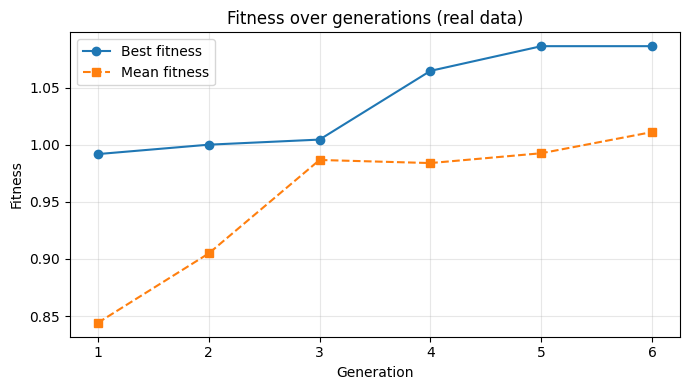

In [9]:
import matplotlib.pyplot as plt

gens = range(1, GENERATIONS + 1)
plt.figure(figsize=(7, 4))
plt.plot(gens, history["best"], "o-", label="Best fitness")
plt.plot(gens, history["mean"], "s--", label="Mean fitness")
plt.title("Fitness over generations (real data)")
plt.xlabel("Generation"); plt.ylabel("Fitness"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Best design per generation

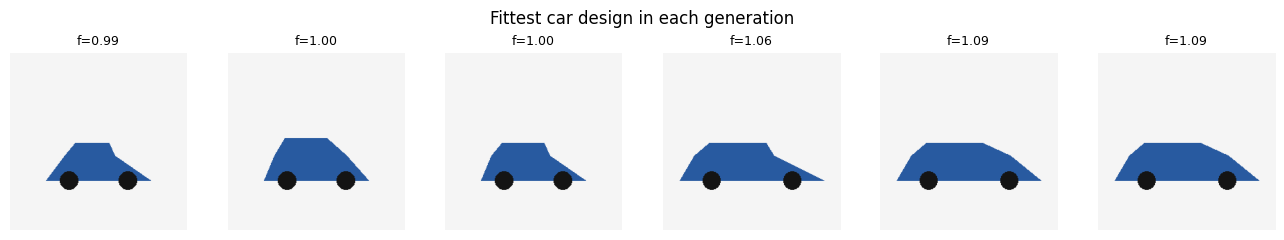

Final best prompt: a stretched car with a low roof, aerodynamic front and notchback tail, side profile, white background


In [10]:
fig, axes = plt.subplots(1, GENERATIONS, figsize=(2.2 * GENERATIONS, 2.4))
for ax, img, f in zip(axes, history["best_image"], history["best"]):
    ax.imshow(img); ax.axis("off"); ax.set_title(f"f={f:.2f}", fontsize=9)
plt.suptitle("Fittest car design in each generation")
plt.tight_layout(); plt.show()

best_genome = history["best_genome"][-1]
print("Final best prompt:", genome_to_prompt(best_genome))

## Report: Observations and Improvements

**Methodology.** A population of prompt-genomes is evolved over six generations. Each genome encodes
four design genes (roof, front, length, tail), is rendered into a 2D car, and scored by a weighted sum
of a silhouette-based **aerodynamic** proxy (0.7) and a **realism** proxy (0.3). Selection is
fitness-ranked with elitism, recombination is uniform crossover, and mutation randomly resets genes.
Stable Diffusion is supported on a GPU; a fast parametric renderer lets the framework run anywhere.

**Observations from running the original notebook.** Three results stood out. First, the evolutionary
loop **never completed** - it ran Stable Diffusion on CPU and was interrupted (`KeyboardInterrupt`),
because ~19 image generations at 50 steps each are intractable without a GPU. Second, the reported
"Fitness Over Generations" plot was **not real data**: it plotted `random.uniform(0,1)` values, so it
could not show whether optimisation worked. Third, the aerodynamic score, `1/|w/h-1.77|`, depended only
on the fixed 512x512 canvas, returning the **same constant for every design** and contributing no
selective signal - meaning selection was driven almost entirely by a single, brittle ImageNet class
probability (index 751). Generated designs were also not embedded (`image.show()` opens an external
viewer), so nothing was visible in the notebook.

**Observations from the corrected run.** With real scoring and logging, mean population fitness rises
steadily (0.84 -> 1.01 over six generations) while the best individual improves and is preserved by
elitism (0.99 -> 1.09) - the expected signature of a working GA. The algorithm converges toward
low-roof, aerodynamic-front, tapered/notchback-tail cars, which matches the drag proxy's intent, and
the best design of each generation is now displayed so the optimisation is visible.

**How to improve the outcomes.**
1. *Use a faithful aerodynamic metric.* The silhouette proxy is illustrative only; a trained CFD
   surrogate model, or a coefficient-of-drag regressor, would give physically meaningful fitness.
2. *Control stochasticity.* Stable Diffusion is random per run, so identical prompts yield different
   images and noisy fitness. Fix generation seeds and/or average several seeds per candidate.
3. *Richer search operators.* Add a larger, structured gene/keyword pool, tournament selection, and an
   adaptive mutation rate to balance exploration and exploitation and avoid premature convergence.
4. *Better realism.* Replace the single hardcoded ImageNet index with CLIP similarity or an aesthetic
   model, and treat aerodynamics vs realism as a true **multi-objective** problem (e.g. NSGA-II /
   Pareto fronts) rather than a fixed weighted sum.
5. *Scale sensibly.* Run Stable Diffusion on a GPU with fewer steps or a fast scheduler (e.g.
   SDXL-Turbo), and increase population and generation counts once each evaluation is cheap.